In [1]:
import numpy as np;
import pandas as pd;
import matplotlib.pyplot as plt;

In [3]:
df = pd.read_csv("../datasets/mnist_dataset.csv");

# Extracting, Feature and Label column from the dataset
X = df.drop('label', axis = 1);
y = df['label']

In [103]:
# Checking the dataset top 5 rows
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [104]:
# Checking the dimensionality of the dataset
df.shape

(42000, 785)

## Splitting the dataset

In [115]:
# Importing train_test_split and dividing the dataset into two parts
from sklearn.model_selection import train_test_split, cross_val_score;
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=0);

## Using KNN on the entire dataset without PCA

In [128]:
from sklearn.neighbors import KNeighborsClassifier;
from sklearn.metrics import accuracy_score;

knn = KNeighborsClassifier();
knn.fit(X_train, y_train);

# Transforming the dataset: Training and Testing
y_test_predicted = knn.predict(X_test);

In [129]:
score = accuracy_score(y_test, y_test_predicted);
score

0.9657142857142857

In [130]:
result = cross_val_score(KNeighborsClassifier(), X, y, scoring= 'accuracy', cv =  5)
np.mean(result)

np.float64(0.965857142857143)

## Performing PCA on the Dataset

In [142]:
from sklearn.decomposition import PCA;
from sklearn.preprocessing import StandardScaler;

In [143]:
scaler = StandardScaler();
X_train_std = scaler.fit_transform(X_train);
X_test_std = scaler.transform(X_test);

X_train_std = pd.DataFrame(X_train_std, columns = X_train.columns);
X_test_std = pd.DataFrame(X_test_std, columns = X_test.columns);

In [144]:
# Here, since the number of components are very high, we can reduce the number of features using Dimenonlity Reduction Technique Like PCA
# Here, 2 means we are taking 2 PCA components along which the spread of the data is maximum: PC1 > PC2 > ... PCn
pca = PCA(n_components=100);
X_train_pca = pca.fit_transform(X_train);
X_test_pca = pca.transform(X_test);

X_train_pca = pd.DataFrame(X_train_pca);
X_test_pca = pd.DataFrame(X_test_pca);

In [145]:
X_train_pca

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,1141.600123,67.903276,-21.949330,-8.795562,-1007.334908,-513.401709,675.285024,-160.115671,383.269039,475.480431,...,17.143619,-1.810666,-101.933180,-17.899940,58.921741,154.592992,-138.426391,0.662309,2.670222,-49.927340
1,-899.263033,627.868015,-360.886343,205.052477,0.557157,-504.230850,241.264379,-79.999875,389.162862,-135.025031,...,-30.848649,-30.362314,-21.495427,-48.591129,-82.594419,-54.268622,-48.463409,49.546491,80.435431,11.064037
2,-203.739935,-783.994248,0.897709,-223.143623,80.421055,182.698213,-270.435956,-243.991983,129.892138,282.594506,...,64.132525,27.409705,-34.871150,-48.878570,112.321829,-6.323304,1.219499,-11.136425,100.421308,-8.458126
3,-794.469635,412.494249,-112.152999,-306.192838,-248.001641,-505.098997,-498.344858,-27.130282,71.930683,41.111876,...,-37.145840,-46.403699,58.901254,-33.542943,2.905393,-38.400493,48.364451,-12.131317,119.992620,-2.525339
4,0.787698,-704.727351,-10.522586,371.734044,34.183892,-380.895829,1063.489370,619.128108,-161.237069,-273.028884,...,21.244436,-63.590359,-39.703829,59.037574,60.619456,-7.424187,-17.690645,-42.413510,9.597918,-56.407581
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29395,477.348956,-44.858339,18.076957,-678.863418,577.211403,657.286663,275.583264,-92.602466,404.965944,-461.673202,...,-34.426040,-77.043951,-86.057436,-23.621729,3.546970,-52.861498,-88.733256,40.024415,58.630875,-45.045446
29396,-714.894847,22.434983,209.927874,-125.163318,-436.264775,411.125860,4.247806,-200.943618,-331.349353,164.946762,...,17.002459,-1.658550,27.752512,41.865518,-39.762929,-43.839185,-31.476587,57.211164,15.614109,-72.188716
29397,-271.688424,-699.974870,637.086791,326.660906,349.071702,158.328737,192.735622,-48.080467,-137.074084,57.551201,...,80.971374,3.970961,-63.567413,-47.092636,-54.436862,45.570862,93.894646,-2.815260,92.505616,16.112349
29398,1487.763389,253.894585,-330.681308,646.752492,-411.737940,476.910575,-53.615176,-270.592905,43.027558,89.568565,...,-47.964691,8.978905,27.284436,-102.576452,28.862157,19.656135,-27.563569,30.272991,127.436441,30.885157


## KNN on the PCA components

In [156]:
knn = KNeighborsClassifier();
knn.fit(X_train_pca, y_train);

# Transforming the dataset: Training and Testing
y_test_predicted = knn.predict(X_test_pca);

score = accuracy_score(y_test, y_test_predicted);
score

0.9681746031746031

In [157]:
pipeline = Pipeline([
    ('pca', PCA(n_components=100)),
    ('knn', KNeighborsClassifier())
])
result = cross_val_score(KNeighborsClassifier(), pd.concat([X_train_pca, X_test_pca]),y, scoring= 'accuracy', cv =  5)
np.mean(result)

np.float64(0.10235714285714285)

## Now, let's visualize these

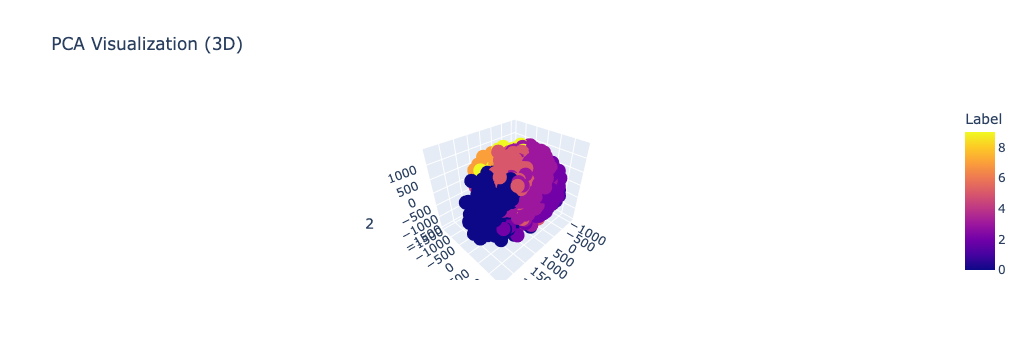

In [172]:
import plotly.express as px
from sklearn.decomposition import PCA

pca = PCA(n_components=3);
X_pca = pca.fit_transform(X);

X_pca = pd.DataFrame(X_pca);
X_pca['Label'] = y


# Plot
fig = px.scatter_3d(
    X_pca,
    x=0,
    y=1,
    z=2,
    color='Label',
    title='PCA Visualization (3D)')

fig.show()

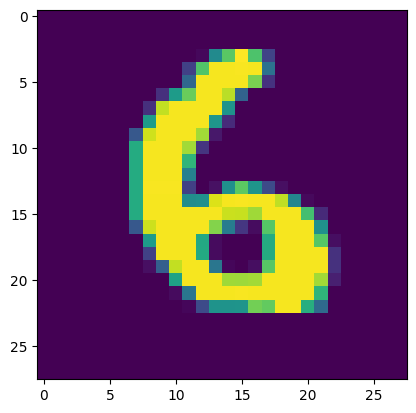

In [47]:
plt.imshow(df.iloc[550].values.reshape(28, 28))

## Practising Removing Skewness from our data

<Axes: ylabel='Density'>

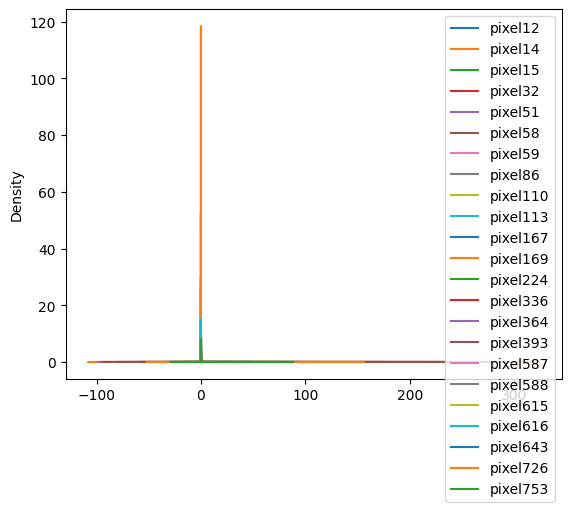

In [90]:
# This dataset is of images pixel. so here outlier we can't simply remove, but consider, if this is important data for other algo
skewness_series = df.skew();
highly_skewed = df.loc[:, skewness_series > 200]
highly_skewed.plot(kind = 'kde')

In [84]:
high_skew_df_quantiles = high_skew_df.quantile([0.25, 0.75]);

outlier_indices = set()

for column in high_skew_df_quantiles.columns:
    val_25 = high_skew_df_quantiles[column].iloc[0]
    val_75 = high_skew_df_quantiles[column].iloc[1]
   
    iqr = val_75 - val_25;
    minimum = val_25 - 1.5*iqr;
    maximum = val_75 + 1.5*iqr;

    indices = high_skew_df[(high_skew_df[column] < minimum) | (high_skew_df[column] > maximum)].index
    outlier_indices.update(indices);

print(outlier_indices)
print(list(outlier_indices))

low_skew_df = high_skew_df.drop(list(outlier_indices))

{20610, 20739, 740, 11909, 26439, 32232, 22509, 24909, 15247, 3952, 29553, 38323, 8019, 30101, 2940, 41598}
[20610, 20739, 740, 11909, 26439, 32232, 22509, 24909, 15247, 3952, 29553, 38323, 8019, 30101, 2940, 41598]


In [85]:
low_skew_df

,pixel14,pixel15,pixel32,pixel58,pixel59,pixel110,pixel113,pixel167,pixel169,pixel224,pixel336,pixel364,pixel587,pixel588,pixel615,pixel616,pixel643,pixel726,pixel753
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
41996,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
41997,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
41998,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [86]:
high_skew_df

,pixel14,pixel15,pixel32,pixel58,pixel59,pixel110,pixel113,pixel167,pixel169,pixel224,pixel336,pixel364,pixel587,pixel588,pixel615,pixel616,pixel643,pixel726,pixel753
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
41996,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
41997,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
41998,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [87]:
high_skew_df.skew()

pixel14     204.939015
pixel15     204.939015
pixel32     204.939015
pixel58     204.939015
pixel59     204.939015
pixel110    204.939015
pixel113    204.939015
pixel167    204.939015
pixel169    204.939015
pixel224    204.939015
pixel336    204.939015
pixel364    204.939015
pixel587    204.939015
pixel588    204.939015
pixel615    204.939015
pixel616    204.939015
pixel643    204.939015
pixel726    204.939015
pixel753    204.939015
dtype: float64

In [89]:
low_skew_df.skew()

pixel14     0.0
pixel15     0.0
pixel32     0.0
pixel58     0.0
pixel59     0.0
pixel110    0.0
pixel113    0.0
pixel167    0.0
pixel169    0.0
pixel224    0.0
pixel336    0.0
pixel364    0.0
pixel587    0.0
pixel588    0.0
pixel615    0.0
pixel616    0.0
pixel643    0.0
pixel726    0.0
pixel753    0.0
dtype: float64